In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pdf = pd.read_csv("Mall_Customers.csv")
pdf.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
pdf.dtypes

CustomerID                int64
Genre                       str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [84]:
clus_data = pdf[["Annual Income (k$)", "Spending Score (1-100)"]]
clus_data.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [85]:
clus_data = clus_data.rename(columns={"Annual Income (k$)": "AI", "Spending Score (1-100)":"SS"})
clus_data.head()

,AI,SS
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [86]:
X = clus_data.values

In [87]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(X)
X[0:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [97]:
from sklearn.cluster import DBSCAN

epsilon = 0.3
minSample = 5

model = DBSCAN(eps=epsilon, min_samples=minSample)
labels = model.fit_predict(X)

print(labels)
print(set(labels))

[ 2  0  1  0  2  0  1 -1  1  0 -1 -1 -1  0  1  0  2  0  2 -1  2  0  1  0
 -1 -1  2 -1  2 -1 -1  0 -1 -1 -1 -1 -1  0 -1  0  3 -1  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  4  3  4  3  4  5  4  5  4  3  4  5  4  5  4  5  4  5  4  3  4
  5  4  3  4  5  4  5  4  5  4  5  4  5  4  5  4  3  4  5  4  6  4  6  4
  6 -1  6  4  6  4  6  4  6  4  6  4 -1  4  6  4 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(-1)}


In [89]:
clus_data["Cluster"] = labels
clus_data.head()

,AI,SS,Cluster
0,15,39,2
1,15,81,0
2,16,6,1
3,16,77,0
4,17,40,2


In [92]:
clus_data = clus_data.groupby("Cluster")

/tmp/ipykernel_12995/3632644886.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subData.AI, subData.SS, c=color, marker="x", s=60)
/tmp/ipykernel_12995/3632644886.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subData.AI, subData.SS, c=color, s=60)


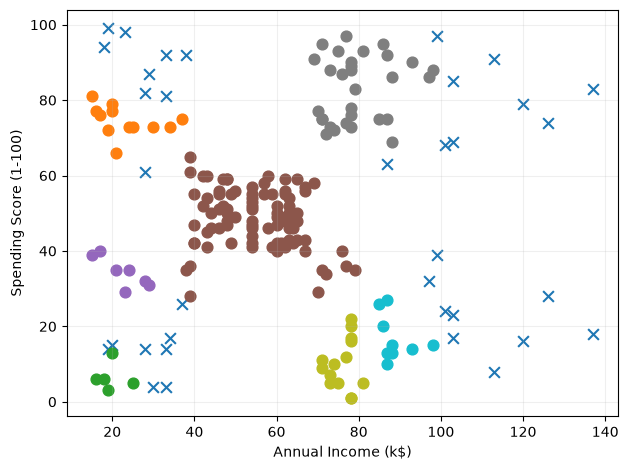

Number of Clusters:  7
Number of Noise points:  35


In [100]:
plt.Figure(figsize=(10, 6))

clusters = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(clusters), 2)))

for color, cluster in zip(colors, clusters):
    subData = clus_data.get_group(cluster)

    if cluster == -1:
        plt.scatter(subData.AI, subData.SS, c=color, marker="x", s=60)
    else:   
        plt.scatter(subData.AI, subData.SS, c=color, s=60)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Number of Clusters: ", len(set(labels) - {-1}))
print("Number of Noise points: ", len(clus_data.get_group(-1).index))